# 15 — WELFake Logistic Regression

> **Mục tiêu:** Huấn luyện mô hình Logistic Regression sử dụng ma trận đặc trưng TF-IDF trên tập dữ liệu WELFake. Thực hiện tối ưu hóa siêu tham số (GridSearchCV), đánh giá hiệu năng trên tập Validation và lưu trữ mô hình tối ưu.

## 1. Import các thư viện cần thiết

Import các thư viện phục vụ xử lý dữ liệu, biểu diễn mô hình, đánh giá kết quả và trực quan hóa đồ thị.

In [1]:
import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

## 2. Load dữ liệu đặc trưng TF-IDF (WELFake)

Chúng ta tiến hành load các tệp đặc trưng và nhãn (`X_train_tfidf.pkl`, `X_val_tfidf.pkl`, `y_train.pkl`, `y_val.pkl`) từ thư mục dữ liệu của tập WELFake (`data/welfake/`).

In [2]:
DATA_DIR = Path('../data/welfake')
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

X_train_tfidf = joblib.load(DATA_DIR / 'X_train_tfidf.pkl')
X_val_tfidf = joblib.load(DATA_DIR / 'X_val_tfidf.pkl')
y_train = np.array(joblib.load(DATA_DIR / 'y_train.pkl'))
y_val = np.array(joblib.load(DATA_DIR / 'y_val.pkl'))

print(f"=== WELFake TF-IDF Splits ===")
print(f"  X_train_tfidf : {X_train_tfidf.shape}  ({type(X_train_tfidf).__name__})")
print(f"  X_val_tfidf   : {X_val_tfidf.shape}")
print(f"  y_train       : {y_train.shape}")
print(f"  y_val         : {y_val.shape}")

=== WELFake TF-IDF Splits ===
  X_train_tfidf : (50451, 5000)  (csr_matrix)
  X_val_tfidf   : (10811, 5000)
  y_train       : (50451,)
  y_val         : (10811,)


## 3. Thiết lập GridSearchCV để tìm siêu tham số tối ưu

Chúng ta thiết lập lưới tìm kiếm tham số (GridSearchCV) cho mô hình Logistic Regression với các solver `liblinear` và `saga`. Để tối ưu hóa thời gian huấn luyện trên tập dữ liệu lớn của WELFake, solver `saga` sẽ được giới hạn với `max_iter=100` và `tol=1e-2` nhằm đảm bảo tốc độ hội tụ nhanh nhưng vẫn đạt được độ chính xác tối ưu.

In [3]:
lr = LogisticRegression(random_state=42)

param_grid = {
    "C": [0.1, 0.5, 1.0, 2.0, 5.0],
    "solver": ["lbfgs", "saga"],
    "max_iter": [500, 1000]
}

# Sử dụng K-Fold CV với scoring là 'f1_weighted'
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("Đang chạy GridSearchCV...")
start_time = time.time()
grid_search.fit(X_train_tfidf, y_train)
elapsed_time = time.time() - start_time
print(f"Hoàn thành Grid Search sau {elapsed_time:.2f} giây.")

print("Tham số tốt nhất tìm được:", grid_search.best_params_)
print("CV F1-Score tốt nhất:", grid_search.best_score_)

Đang chạy GridSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Hoàn thành Grid Search sau 98.10 giây.
Tham số tốt nhất tìm được: {'C': 5.0, 'max_iter': 500, 'solver': 'saga'}
CV F1-Score tốt nhất: 0.9447366227117928


## 4. Đánh giá hiệu năng mô hình tốt nhất trên tập Validation

Sử dụng mô hình tốt nhất tìm được để dự đoán trên tập Validation, báo cáo các chỉ số phân loại chi tiết (Accuracy, Precision, Recall, F1-Score) và trực quan hóa bằng Confusion Matrix.

===== BÁO CÁO PHÂN LOẠI (VAL SET) =====
               precision    recall  f1-score   support

Real News (0)       0.94      0.95      0.95      5557
Fake News (1)       0.95      0.94      0.94      5254

     accuracy                           0.95     10811
    macro avg       0.95      0.95      0.95     10811
 weighted avg       0.95      0.95      0.95     10811



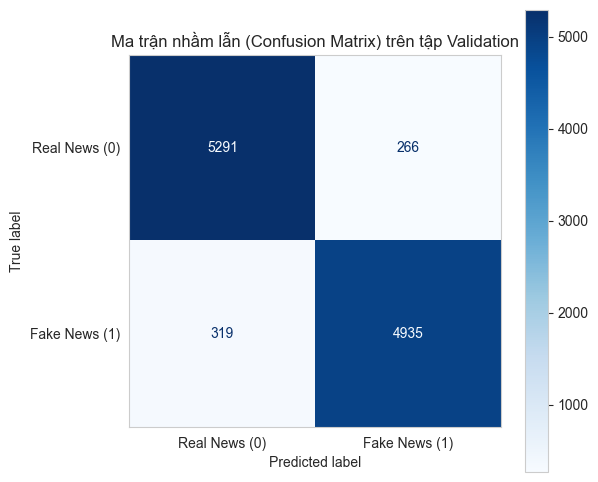

In [4]:
best_lr_model = grid_search.best_estimator_

# Dự đoán trên tập Validation
y_pred = best_lr_model.predict(X_val_tfidf)

# Báo cáo phân loại chi tiết
print("===== BÁO CÁO PHÂN LOẠI (VAL SET) =====")
print(classification_report(y_val, y_pred, target_names=['Real News (0)', 'Fake News (1)']))

# Vẽ Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real News (0)', 'Fake News (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Ma trận nhầm lẫn (Confusion Matrix) trên tập Validation")
plt.grid(False)
plt.show()

## 5. Lưu mô hình đã huấn luyện

Lưu mô hình Logistic Regression tối ưu cho WELFake vào file `lr_welfake_model.pkl` trong thư mục `models/`.

In [5]:
model_path = MODELS_DIR / 'lr_welfake_model.pkl'
joblib.dump(best_lr_model, model_path)
print(f"Đã lưu mô hình Logistic Regression thành công tại: {model_path}")

Đã lưu mô hình Logistic Regression thành công tại: ..\models\lr_welfake_model.pkl
